In [2]:
import pandas as pd
import numpy as np

# 1. Load Data
CSV_PATH = r"C:\Project\data\processed\clean_prices_festivals_2010_2016.csv"
df_raw = pd.read_csv(CSV_PATH)
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])

# Clean and aggregate daily entries (preserving tithi and hindu_month)
df = df_raw.groupby('DATE').agg({
    'festival_name': lambda x: ' | '.join(sorted(x.dropna().astype(str).unique())) if len(x.dropna()) > 0 else None,
    'tithi': 'first',
    'hindu_month': 'first',
    'price': 'first'
}).reset_index().sort_values('DATE')

# Ensure is_festival is strictly integer 0 or 1 (Day Type column dropped)
df['is_festival'] = df['festival_name'].notna().astype(int)

# Cast price to float to accept decimal averages without throwing a TypeError
df['price_updated'] = df['price'].astype(float)

# 2. Identify Outlier Condition (Price < 50 or Price > 1000)
condition = (df['price'] < 50) | (df['price'] > 1000)
outlier_rows = df[condition]

# 3. Custom Function: Average of Previous 2 Days and Next 2 Days
def calc_surrounding_avg(series, idx):
    prev_2 = series.iloc[max(0, idx - 2):idx]
    next_2 = series.iloc[idx + 1:min(len(series), idx + 3)]
    surrounding_vals = pd.concat([prev_2, next_2])
    return surrounding_vals.mean()

# 4. Apply Replacement Only to Outliers
for idx in outlier_rows.index:
    surrounding_avg = calc_surrounding_avg(df['price'], idx)
    df.loc[idx, 'price_updated'] = round(surrounding_avg, 2)

# 5. Export directly to a new CSV file
OUTPUT_CSV_PATH = r"C:\Project\data\processed\flower_prices_cleaned.csv"
df.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"Cleaned dataset successfully saved to '{OUTPUT_CSV_PATH}'")

Cleaned dataset successfully saved to 'C:\Project\data\processed\flower_prices_cleaned.csv'


1. STATISTICAL COMPARISON TABLE: RAW vs. CLEANED DATA
                        Raw Dataset (With Outliers)  Cleaned Dataset  Absolute Difference  % Shift
Total Records                              2557.000         2557.000                0.000     0.00
Mean (₹)                                    360.750          359.820               -0.930    -0.26
Std Dev (₹)                                 226.660          220.840               -5.820    -2.57
Min Price (₹)                                10.000           50.000               40.000   400.00
25th Percentile Q1 (₹)                      170.000          170.000                0.000     0.00
Median / 50th % (₹)                         310.000          310.000                0.000     0.00
75th Percentile Q3 (₹)                      460.000          460.000                0.000     0.00
Max Price (₹)                              2909.000          820.000            -2089.000   -71.81
Skewness                                      1.323    

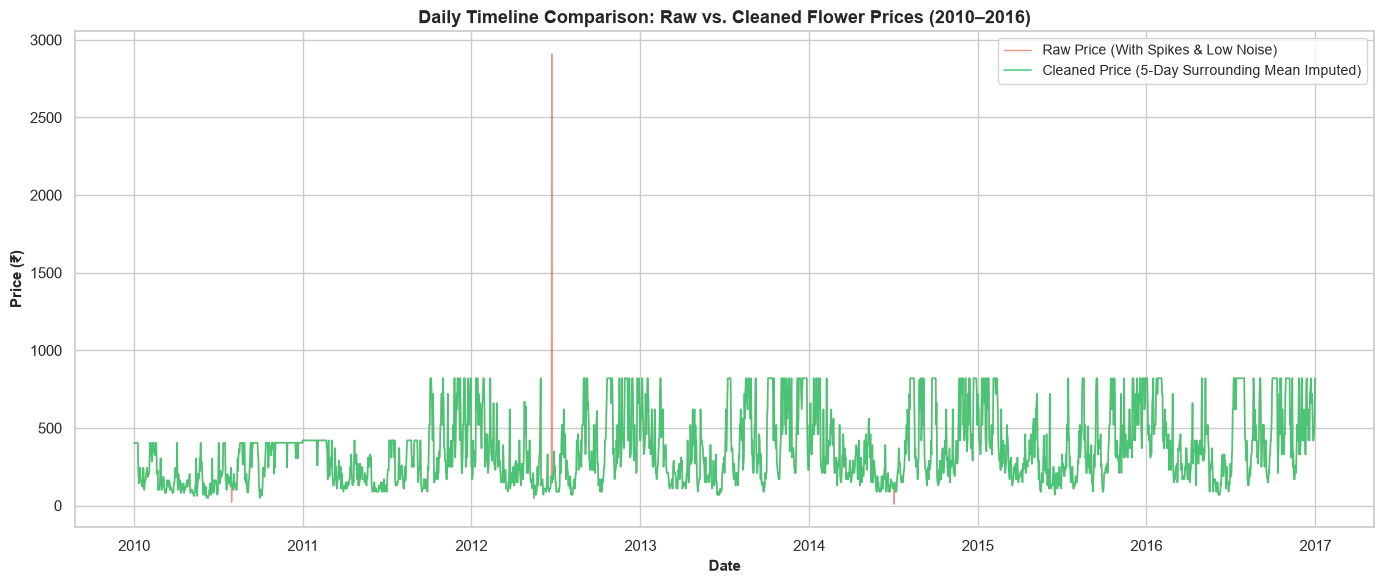

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. LOAD BOTH DATASETS
# =========================================================================
RAW_CSV = r"C:\Project\data\processed\clean_prices_festivals_2010_2016.csv"
CLEAN_CSV = r"C:\Project\data\processed\flower_prices_cleaned.csv"

df_raw = pd.read_csv(RAW_CSV)
df_clean = pd.read_csv(CLEAN_CSV)

# Ensure DATE columns are in datetime format
df_raw['DATE'] = pd.to_datetime(df_raw['DATE'])
df_clean['DATE'] = pd.to_datetime(df_clean['DATE'])

# Identify appropriate price columns
raw_price_col = 'price'
if 'price_updated' in df_clean.columns:
    clean_price_col = 'price_updated'
elif 'price_cleaned' in df_clean.columns:
    clean_price_col = 'price_cleaned'
else:
    clean_price_col = 'price'

# =========================================================================
# 2. CALCULATE & PRINT STATISTICAL COMPARISON TABLE
# =========================================================================
def get_metrics(series):
    return {
        'Total Records': series.count(),
        'Mean (₹)': round(series.mean(), 2),
        'Std Dev (₹)': round(series.std(), 2),
        'Min Price (₹)': round(series.min(), 2),
        '25th Percentile Q1 (₹)': round(series.quantile(0.25), 2),
        'Median / 50th % (₹)': round(series.median(), 2),
        '75th Percentile Q3 (₹)': round(series.quantile(0.75), 2),
        'Max Price (₹)': round(series.max(), 2),
        'Skewness': round(series.skew(), 3)
    }

raw_stats = get_metrics(df_raw[raw_price_col])
clean_stats = get_metrics(df_clean[clean_price_col])

comparison_table = pd.DataFrame({
    'Raw Dataset (With Outliers)': raw_stats,
    'Cleaned Dataset': clean_stats
})

comparison_table['Absolute Difference'] = (
    comparison_table['Cleaned Dataset'] - comparison_table['Raw Dataset (With Outliers)']
)
comparison_table['% Shift'] = round(
    (comparison_table['Absolute Difference'] / comparison_table['Raw Dataset (With Outliers)'].replace(0, np.nan)) * 100, 2
)

print("=" * 85)
print("1. STATISTICAL COMPARISON TABLE: RAW vs. CLEANED DATA")
print("=" * 85)
print(comparison_table.to_string())

# =========================================================================
# 3. PRINT KEY DATA QUALITY IMPROVEMENT METRICS
# =========================================================================
std_reduction = round((1 - (df_clean[clean_price_col].std() / df_raw[raw_price_col].std())) * 100, 2)
max_range_reduction = round(df_raw[raw_price_col].max() - df_clean[clean_price_col].max(), 2)

print("\n" + "=" * 85)
print("2. KEY DATA QUALITY IMPROVEMENT METRICS")
print("=" * 85)
print(f"• Noise Reduction (Std Dev Drop) : Volatility reduced by {std_reduction}%")
print(f"• Anomaly Range Capping          : Peak price spike reduced by ₹{max_range_reduction}")
print(f"• Baseline Floor Lift            : Noise floor lifted from ₹{df_raw[raw_price_col].min()} to ₹{df_clean[clean_price_col].min()}")

# =========================================================================
# 4. SINGLE COMPARATIVE TIMELINE GRAPH
# =========================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

plt.plot(
    df_raw['DATE'], 
    df_raw[raw_price_col], 
    color='#e74c3c', 
    alpha=0.6, 
    linewidth=1, 
    label='Raw Price (With Spikes & Low Noise)'
)

plt.plot(
    df_clean['DATE'], 
    df_clean[clean_price_col], 
    color='#2ecc71', 
    alpha=0.85, 
    linewidth=1.2, 
    label='Cleaned Price (5-Day Surrounding Mean Imputed)'
)

plt.title('Daily Timeline Comparison: Raw vs. Cleaned Flower Prices (2010–2016)', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11, fontweight='bold')
plt.ylabel('Price (₹)', fontsize=11, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()

plt.show()